# SurvArena Quickstart: Survival AutoML Walkthrough on GBSG2

This notebook shows how to use SurvArena much like an AutoML workflow for survival analysis, using the built-in `gbsg2` breast cancer dataset.

By the end, you will know how to:

1. load a survival dataset from the repo
2. understand the `time` and `event` labels
3. train an AutoML-style `SurvivalPredictor`
4. compare candidate models in a leaderboard
5. generate risk scores and survival curves
6. visualize model behavior in a way that is useful for scientists
7. save and reload the fitted predictor


## Why survival modeling is different from ordinary regression or classification

A survival dataset usually has two target columns:

- `time`: how long a subject was followed
- `event`: whether the event of interest was actually observed (`1`) or the subject was right censored (`0`)

Right censoring means we know a patient survived at least until their last follow-up, but we do not know what happened after that point. Survival models are designed to use both the observed event times and the censored follow-up times correctly.

The SurvArena workflow is intentionally close to an AutoML experience:

1. put your features and survival labels in one table
2. tell the predictor which columns are `time` and `event`
3. call `fit(...)`
4. inspect a leaderboard and generate predictions


In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/survarena_mplconfig")
os.environ.setdefault("XDG_CACHE_HOME", "/tmp/survarena_xdg_cache")

repo_root = Path.cwd().resolve()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split

from survarena import SurvivalPredictor
from survarena.data.loaders import load_dataset

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

print(f"Repo root: {repo_root}")


Repo root: /Users/justin/Documents/SurvArena


## Step 1: Load one of SurvArena's built-in benchmark datasets

For this walkthrough we will use `gbsg2`, a compact and well-known clinical survival dataset. It is a good teaching example because:

- it is small enough to train quickly
- it includes both numerical and categorical predictors
- it has real censoring, so the full survival workflow matters

The repo loader returns a `SurvivalDataset` object with features, labels, and metadata. We then combine the labels back into one DataFrame because that is the user-facing pattern expected by `SurvivalPredictor`.


In [2]:
dataset = load_dataset("gbsg2", repo_root)

df = dataset.X.copy()
df["time"] = dataset.time
df["event"] = dataset.event

overview = pd.DataFrame(
    {
        "quantity": [
            "rows",
            "feature columns",
            "observed events",
            "right censored",
            "event rate",
            "median follow-up time",
        ],
        "value": [
            len(df),
            dataset.X.shape[1],
            int(df["event"].sum()),
            int((1 - df["event"]).sum()),
            f"{df['event'].mean():.1%}",
            f"{df['time'].median():.1f}",
        ],
    }
)

display(overview)
display(df.head())


,quantity,value
0,rows,686
1,feature columns,8
2,observed events,387
3,right censored,299
4,event rate,56.4%
5,median follow-up time,1084.0


,age,estrec,horTh,menostat,pnodes,progrec,tgrade,tsize,time,event
0,70.0,66.0,no,Post,3.0,48.0,II,21.0,1814.0,0
1,56.0,77.0,yes,Post,7.0,61.0,II,12.0,2018.0,0
2,58.0,271.0,yes,Post,9.0,52.0,II,35.0,712.0,0
3,59.0,29.0,yes,Post,4.0,60.0,II,17.0,1807.0,0
4,73.0,65.0,no,Post,1.0,26.0,II,35.0,772.0,0


## Step 2: Inspect the survival labels before modeling

This is a good habit for every new survival project.

- If `event = 1`, the event was observed.
- If `event = 0`, the observation is censored.
- The `time` column is still useful in both cases because it tells us how long the subject was known to remain event-free.

A quick visual check helps confirm that the label distributions look reasonable before we train anything.


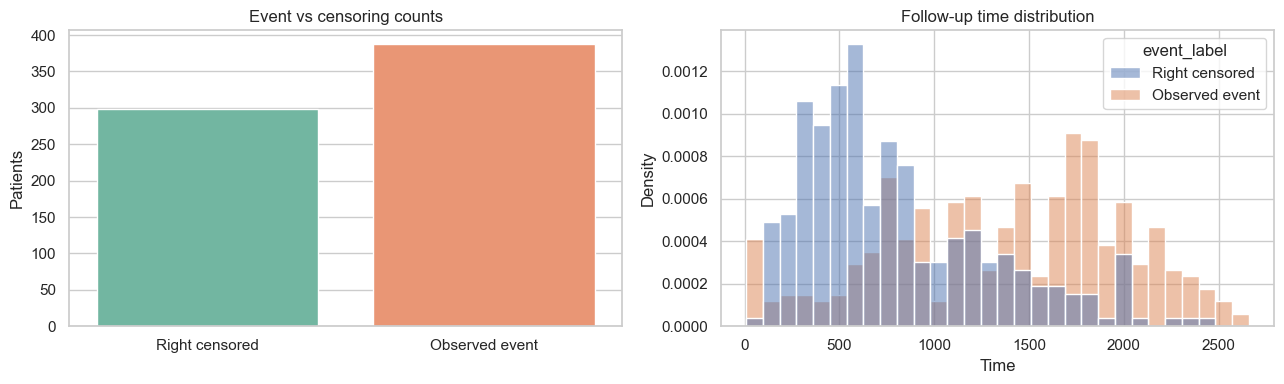

In [3]:
label_frame = df.assign(
    event_label=np.where(df["event"] == 1, "Observed event", "Right censored")
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.countplot(data=label_frame, x="event_label", hue="event_label", ax=axes[0], palette="Set2", legend=False)
axes[0].set_title("Event vs censoring counts")
axes[0].set_xlabel("")
axes[0].set_ylabel("Patients")

sns.histplot(
    data=label_frame,
    x="time",
    hue="event_label",
    bins=30,
    stat="density",
    common_norm=False,
    ax=axes[1],
)
axes[1].set_title("Follow-up time distribution")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()


## Step 3: Create a training split and a held-out test split

AutoML systems still need a fair evaluation strategy. Here we create a simple train/test split and stratify on the event indicator so both partitions have a similar event rate.

For a first notebook, this is usually easier to understand than full nested cross-validation.


In [4]:
train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["event"],
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

split_summary = pd.DataFrame(
    {
        "split": ["train", "test"],
        "rows": [len(train_df), len(test_df)],
        "event_rate": [train_df["event"].mean(), test_df["event"].mean()],
        "median_time": [train_df["time"].median(), test_df["time"].median()],
    }
)

display(split_summary)


,split,rows,event_rate,median_time
0,train,548,0.563869,981.5
1,test,138,0.565217,1194.0


## Step 4: Fit `SurvivalPredictor` in an AutoML-style way (fresh run)

This is the core SurvArena user experience.

To keep this notebook fully reproducible and avoid confusion with older artifacts, we remove any prior `gbsg2_quickstart` outputs before calling `fit(...)`.

Important arguments:

- `label_time` and `label_event`: tell SurvArena where the survival labels live
- `presets='fast'`: run a small portfolio quickly for a first pass
- `eval_metric='harrell_c'`: rank models by Harrell's concordance index
- `random_state`: make the run reproducible

The `fast` preset is a good place to start. After you understand the workflow, you can switch to `medium` for a broader search.


In [12]:
import shutil

artifact_root = repo_root / "examples" / "results" / "predictor"
dataset_name = "gbsg2_quickstart"

# Force a fresh run by clearing prior quickstart artifacts.
shutil.rmtree(artifact_root / dataset_name, ignore_errors=True)
for stale_file in [
    artifact_root / f"{dataset_name}.pkl",
    artifact_root / f"{dataset_name}_manifest.json",
]:
    stale_file.unlink(missing_ok=True)

predictor = SurvivalPredictor(
    label_time="time",
    label_event="event",
    presets="medium",
    eval_metric="harrell_c",
    random_state=42,
    save_path=artifact_root,
)

predictor.fit(
    train_df,
    test_data=test_df,
    dataset_name=dataset_name,
)

print("Trained models:", predictor.model_names())
print("Best model:", predictor.best_method_id_)


/Users/justin/Documents/SurvArena/survarena/methods/deep/deepsurv.py:105: UserWarning: Ties in `time` detected; using efron method to handle ties.
  return neg_partial_log_likelihood(log_hazard, event, time)
/Users/justin/Documents/SurvArena/survarena/methods/deep/deepsurv.py:105: UserWarning: Ties in `time` detected; using efron method to handle ties.
  return neg_partial_log_likelihood(log_hazard, event, time)
/Users/justin/Documents/SurvArena/survarena/methods/deep/deepsurv.py:105: UserWarning: Ties in `time` detected; using efron method to handle ties.
  return neg_partial_log_likelihood(log_hazard, event, time)


Trained models: ['coxph', 'coxnet', 'rsf', 'deepsurv']
Best model: deepsurv


## Step 5: Read the leaderboard

This is the SurvArena equivalent of an AutoML comparison table.

Useful interpretation tips:

- higher `validation_harrell_c` is better
- higher `test_harrell_c` is better
- lower `ibs` is better because it is an error measure
- `params` shows the selected hyperparameters for that candidate model

Start by focusing on a few columns, then look at the full table if needed.


In [13]:
leaderboard = predictor.leaderboard()

display(
    leaderboard[
        [
            "rank",
            "method_id",
            "validation_harrell_c",
            "test_harrell_c",
            "validation_ibs",
            "test_ibs",
            "fit_time_sec",
            "params",
        ]
    ]
)


,rank,method_id,validation_harrell_c,test_harrell_c,validation_ibs,test_ibs,fit_time_sec,params
0,1,deepsurv,0.532163,0.545304,0.155900,0.166639,26.723380,"{'hidden_layers': '128', 'activation': 'gelu',..."
1,2,rsf,0.526788,0.534658,0.162581,0.160715,7.312793,"{'n_estimators': 158, 'max_depth': 25, 'min_sa..."
2,3,coxnet,0.513866,0.539153,0.158829,0.161020,0.278357,"{'alpha': 0.00017670169402947956, 'l1_ratio': ..."
3,4,coxph,0.513861,0.540099,0.158822,0.160996,0.690303,{'alpha': 0.5061576888752303}


## Step 6: Inspect the fit summary and dataset diagnostics

The fit summary is a compact record of what happened during training. It is especially useful for scientific workflows because it records:

- which model won
- which preset was used
- which models were trained
- where artifacts were saved
- basic diagnostics about the dataset


In [14]:
fit_summary = predictor.fit_summary()

summary_view = pd.DataFrame(
    {
        "item": [
            "best_method_id",
            "preset",
            "selection_metric",
            "trained_models",
            "artifact_dir",
        ],
        "value": [
            fit_summary["best_method_id"],
            fit_summary["preset"],
            fit_summary["selection_metric"],
            ", ".join(fit_summary["trained_models"]),
            fit_summary.get("artifact_dir"),
        ],
    }
)

display(summary_view)
display(pd.Series(fit_summary["dataset_diagnostics"], name="dataset_diagnostics"))


,item,value
0,best_method_id,deepsurv
1,preset,medium
2,selection_metric,harrell_c
3,trained_models,"coxph, coxnet, rsf, deepsurv"
4,artifact_dir,/Users/justin/Documents/SurvArena/examples/res...


n_rows                                                      548
n_features                                                    8
n_events                                                    309
event_rate                                             0.563869
censoring_rate                                         0.436131
missing_fraction                                            0.0
feature_type_counts          {'numerical': 5, 'categorical': 3}
high_cardinality_features                                    []
id_like_features                                             []
warnings                                                     []
Name: dataset_diagnostics, dtype: object

## Step 7: Generate predictions

SurvArena exposes two main prediction types:

- `predict_risk(...)`: one relative risk score per patient
- `predict_survival(...)`: a full survival curve for each patient over time

A higher risk score means the model believes that patient is more likely to experience the event earlier, relative to other patients in the same dataset.


In [15]:
risk_scores = predictor.predict_risk(test_df)
survival_df = predictor.predict_survival(test_df)

prediction_view = test_df[["time", "event"]].copy()
prediction_view["predicted_risk"] = risk_scores
prediction_view["risk_percentile"] = pd.Series(risk_scores).rank(pct=True)

display(prediction_view.sort_values("predicted_risk", ascending=False).head(10))
display(survival_df.iloc[:5, :8])


,time,event,predicted_risk,risk_percentile
74,1767.0,1,1.198471,1.000000
41,1329.0,0,1.098565,0.992754
67,1856.0,1,1.026139,0.985507
98,747.0,0,1.006895,0.978261
125,1878.0,1,1.004790,0.971014
44,828.0,1,0.978632,0.963768
105,455.0,0,0.944945,0.956522
62,98.0,0,0.772109,0.949275
33,740.0,1,0.716877,0.942029
12,1349.0,1,0.711523,0.934783


,t_219.4,t_261.576,t_303.751,t_345.927,t_388.102,t_430.278,t_472.453,t_514.629
0,0.989416,0.988509,0.986560,0.984649,0.984339,0.982995,0.980702,0.979678
1,0.990827,0.990041,0.988350,0.986692,0.986422,0.985256,0.983266,0.982376
2,0.982467,0.980970,0.977756,0.974610,0.974099,0.971889,0.968124,0.966444
3,0.981971,0.980432,0.977129,0.973895,0.973370,0.971099,0.967230,0.965503
4,0.961437,0.958182,0.951218,0.944427,0.943326,0.938575,0.930510,0.926924


## Step 8: Plot a few individual survival curves

A survival curve gives the model's estimated probability that a patient remains event-free beyond each time point.

In general:

- curves that stay higher for longer imply better predicted prognosis
- curves that drop early imply higher predicted risk

Below we plot a few low-risk and high-risk patients from the test set.


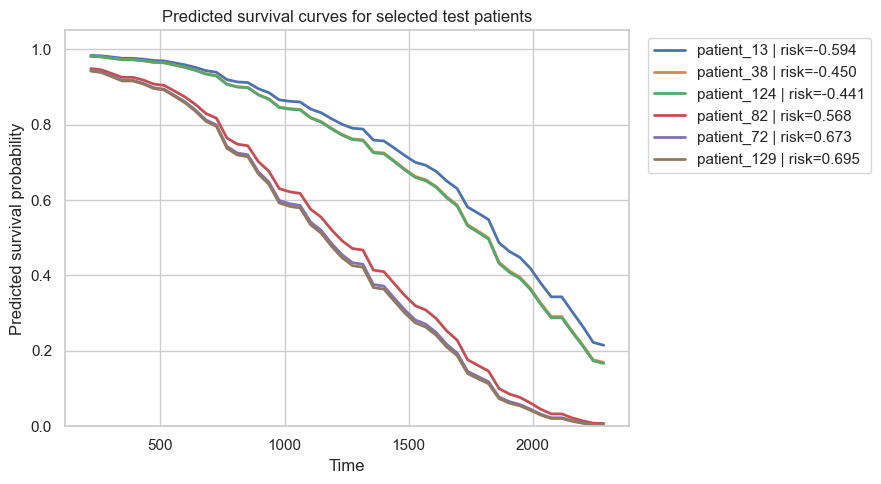

In [9]:
survival_times = np.array([float(col.replace("t_", "")) for col in survival_df.columns])
ranked_indices = np.argsort(risk_scores)
selected_indices = list(ranked_indices[:3]) + list(ranked_indices[-3:])

fig, ax = plt.subplots(figsize=(9, 5))
for idx in selected_indices:
    label = f"patient_{idx} | risk={risk_scores[idx]:.3f}"
    ax.plot(survival_times, survival_df.iloc[idx].to_numpy(), linewidth=2, label=label)

ax.set_title("Predicted survival curves for selected test patients")
ax.set_xlabel("Time")
ax.set_ylabel("Predicted survival probability")
ax.set_ylim(0.0, 1.05)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Step 9: Compare empirical Kaplan-Meier curves with model predictions

This is a particularly nice scientist-friendly diagnostic.

SurvArena splits patients into risk groups based on predicted risk, then overlays:

- empirical Kaplan-Meier survival curves from the observed data
- the model's mean predicted survival curve for each risk group

If the model is behaving sensibly, the higher-risk group should show worse survival than the lower-risk group.


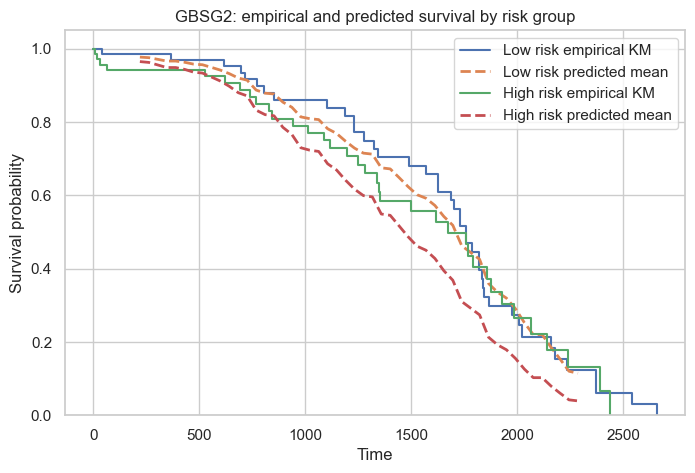

In [10]:
ax = predictor.plot_kaplan_meier_comparison(
    test_df,
    n_groups=2,
    title="GBSG2: empirical and predicted survival by risk group",
)
plt.show()


## Step 10 (optional): Save and reload the fitted predictor

The core workflow above trains from scratch. This section is optional and only demonstrates persistence after training is complete.


In [11]:
RUN_PERSISTENCE_DEMO = False

if RUN_PERSISTENCE_DEMO:
    model_path = predictor.save(artifact_root / f"{dataset_name}.pkl")
    reloaded_predictor = SurvivalPredictor.load(model_path)

    reload_summary = pd.DataFrame(
        {
            "check": [
                "saved_path",
                "best_method_id",
                "trained_models",
                "risk_predictions_match",
            ],
            "value": [
                str(model_path),
                reloaded_predictor.best_method_id_,
                ", ".join(reloaded_predictor.model_names()),
                np.allclose(reloaded_predictor.predict_risk(test_df), risk_scores),
            ],
        }
    )

    display(reload_summary)
else:
    print("Persistence demo skipped. Set RUN_PERSISTENCE_DEMO=True to save/reload.")


,check,value
0,saved_path,/Users/justin/Documents/SurvArena/examples/res...
1,best_method_id,coxph
2,trained_models,"coxph, rsf"
3,risk_predictions_match,True


## How to adapt this notebook to your own data

Once you understand the workflow above, the user-owned version is very small.

```python
import pandas as pd
from survarena import SurvivalPredictor

my_df = pd.read_csv("my_survival_data.csv")

predictor = SurvivalPredictor(
    label_time="follow_up_time",
    label_event="event_observed",
    presets="medium",
    eval_metric="harrell_c",
    random_state=42,
)

predictor.fit(my_df)
leaderboard = predictor.leaderboard()
risk_scores = predictor.predict_risk(my_df)
survival_curves = predictor.predict_survival(my_df)
```

Practical guidance:

- start with `presets='fast'` to confirm the pipeline works
- switch to `presets='medium'` for a stronger baseline portfolio
- keep `time` numeric and `event` binary
- treat the risk score as a relative ranking, not a probability
- use predicted survival curves when you need time-specific interpretation


## Suggested next experiments

If you want to keep exploring, good next steps are:

1. rerun the notebook with `presets='medium'`
2. try a different built-in dataset such as `support` or `metabric`
3. compare how risk ranking changes across models by requesting a specific model in `predict_risk(..., model='coxph')`
4. bring in your own CSV or Parquet file and keep the rest of the workflow the same
